# 라이브러리 불러오기 및 초기 설정

In [2]:
# -*- coding: utf-8 -*-

import os
import sys
import platform
import requests
from io import BytesIO

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import warnings

warnings.filterwarnings('ignore')
plt.style.use('default')
plt.rcParams['figure.figsize'] = (15, 10)

# ---------------------------
# 설정: 출력 옵션, 폰트 (안전하게 처리)
# ---------------------------
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

def setup_font(preferred_paths=None):
    """OS에 따라 한글 폰트를 시도해서 설정합니다. 실패하면 기본 폰트 사용."""
    if preferred_paths is None:
        preferred_paths = []
    # Windows 기본
    preferred_paths += [
        'C:/Windows/Fonts/malgun.ttf',  # 맑은 고딕
        '/usr/share/fonts/truetype/nanum/NanumGothic.ttf',  # 리눅스 예시
        '/Library/Fonts/AppleSDGothicNeo.ttc'  # 맥 예시
    ]
    for p in preferred_paths:
        if os.path.exists(p):
            try:
                name = fm.FontProperties(fname=p).get_name()
                plt.rc('font', family=name)
                return
            except Exception:
                continue
    # 실패 시 matplotlib 기본 폰트 사용
    return

setup_font()

# 데이터 로드
깃허브에서 원본 다운받아 전역 변수로 저장

In [3]:
import os
import pandas as pd
import requests

# ==========================================
# 설정: 로컬에서 작업할 때는 True, 깃허브에서 불러올 때는 False
# ==========================================
LOCAL_MODE = True  
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

URLS = {
    "AdmissionsCorePopulatedTable": "https://raw.githubusercontent.com/tashydean/Basic_Health_Care/refs/heads/master/Data_Files/AdmissionsCorePopulatedTable.txt",
    "AdmissionsDiagnosesCorePopulatedTable": "https://raw.githubusercontent.com/tashydean/Basic_Health_Care/refs/heads/master/Data_Files/AdmissionsDiagnosesCorePopulatedTable.txt",
    "LabsCorePopulatedTable": "https://raw.githubusercontent.com/tashydean/Basic_Health_Care/refs/heads/master/Data_Files/LabsCorePopulatedTable.txt",
    "PatientCorePopulatedTable": "https://raw.githubusercontent.com/tashydean/Basic_Health_Care/refs/heads/master/Data_Files/PatientCorePopulatedTable.txt"
}

# ---------------------------
# 유틸리티 함수들
# ---------------------------
def download_to_path(url, dest_path):
    """URL에서 파일을 다운로드."""
    print(f"Downloading from GitHub -> {dest_path}...")
    r = requests.get(url)
    r.raise_for_status()
    with open(dest_path, 'wb') as f:
        f.write(r.content)

def read_table_with_schema(path, schema):
    """지정한 스키마로 파일 읽기."""
    df = pd.read_csv(path, sep='\t', skiprows=1, header=None, names=schema['names'], dtype=str)
    if schema.get('coerce_numeric'):
        for c in schema['coerce_numeric']:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    return df

def load_all_data(mode_local=True):
    """로컬 혹은 온라인에서 데이터를 로드하고 전역 변수 생성."""
    data_frames = {}
    schemas = {
        "AdmissionsCorePopulatedTable": {"names": ["PatientID","AdmissionID","AdmissionStartDate","AdmissionEndDate"], "coerce_numeric": []},
        "AdmissionsDiagnosesCorePopulatedTable": {"names": ["PatientID","AdmissionID","PrimaryDiagnosisCode","PrimaryDiagnosisDescription"], "coerce_numeric": []},
        "LabsCorePopulatedTable": {"names": ["PatientID","AdmissionID","LabName","LabValue","LabUnits","LabDateTime"], "coerce_numeric": ["LabValue"]},
        "PatientCorePopulatedTable": {"names": ["PatientID","PatientGender","PatientDateOfBirth","PatientRace","PatientMaritalStatus","PatientLanguage","PatientPopulationPercentageBelowPoverty"], "coerce_numeric": ["PatientPopulationPercentageBelowPoverty"]}
    }
    
    mapping = {
        "AdmissionsCorePopulatedTable": "df_ACPT",
        "AdmissionsDiagnosesCorePopulatedTable": "df_ADCPT",
        "LabsCorePopulatedTable": "df_LCPT",
        "PatientCorePopulatedTable": "df_PCPT"
    }

    for key, url in URLS.items():
        local_path = os.path.join(DATA_DIR, f"{key}.txt")
        
        if mode_local:
            # 로컬 모드: 파일이 있는지 확인만 함
            if not os.path.exists(local_path):
                print(f"⚠️ 로컬 파일이 없습니다. 다운로드를 시도합니다: {key}")
                download_to_path(url, local_path)
        else:
            # 온라인 모드: 항상 다운로드 (혹은 덮어쓰기)
            download_to_path(url, local_path)
            
        df = read_table_with_schema(local_path, schemas[key])
        data_frames[key] = df
        globals()[mapping[key]] = df  # 전역 변수 생성
        
    print("✅ 모든 데이터 로드 완료!")
    return data_frames

# 데이터 로드 실행
data_frames = load_all_data(mode_local=LOCAL_MODE)

✅ 모든 데이터 로드 완료!


# 공통 전처리

In [4]:

# ---------------------------
# 공통 전처리 (날짜, 카테고리, 숫자 등)
# ---------------------------
def common_preprocess(dfs):
    """날짜형 변환, 범주형 변환, 숫자 변환을 일괄 처리."""
    date_cols = ['LabDateTime','PatientDateOfBirth','AdmissionStartDate','AdmissionEndDate']
    for key, df in dfs.items():
        for col in date_cols:
            if col in df.columns:
                df[col] = pd.to_datetime(df[col], errors='coerce')
    # AdmissionID 범주형(ordered)
    for key, df in dfs.items():
        if 'AdmissionID' in df.columns:
            df['AdmissionID'] = df['AdmissionID'].astype('category').cat.as_ordered()
    # 인구통계 범주형
    cat_cols = ['PatientGender','PatientRace','PatientMaritalStatus','PatientLanguage','PrimaryDiagnosisCode','LabName']
    for key, df in dfs.items():
        for col in cat_cols:
            if col in df.columns:
                df[col] = df[col].astype('category')
    # 빈곤율 숫자 변환
    for key, df in dfs.items():
        if 'PatientPopulationPercentageBelowPoverty' in df.columns:
            df['PatientPopulationPercentageBelowPoverty'] = pd.to_numeric(df['PatientPopulationPercentageBelowPoverty'], errors='coerce')

common_preprocess(data_frames)

# 각 DataFrame을 전역 변수로 다시 바인딩 (편의)
df_PCPT = globals().get('df_PCPT')
df_ACPT = globals().get('df_ACPT')
df_ADCPT = globals().get('df_ADCPT')
df_LCPT = globals().get('df_LCPT')

# ---------------------------
# 일반적인 EDA 유틸 (원본 코드의 출력 포맷을 유지)
# ---------------------------
def general_overview(df, name):
    print(f"\n------------------------ {name} 데이터프레임 기초 분석 시작 ------------------------")
    # 1. 데이터 타입
    print(df.dtypes)
    # 2. 결측치
    print("결측치 개수 : ")
    print(df.isnull().sum())
    # 3. head, describe, 중복 등
    print(df.head())
    print(df.describe(include='all', datetime_is_numeric=True))
    print('중복된 행 수:', df.duplicated().sum())
    print('중복 행 예시 : ')
    if df.duplicated().sum() > 0:
        print(df[df.duplicated()].head())
    else:
        print("중복 없음")

# 원본에서 했던 기본 EDA (모든 df에 대해)
for key, df in data_frames.items():
    general_overview(df, key)


------------------------ AdmissionsCorePopulatedTable 데이터프레임 기초 분석 시작 ------------------------
PatientID                     object
AdmissionID                 category
AdmissionStartDate    datetime64[ns]
AdmissionEndDate      datetime64[ns]
dtype: object
결측치 개수 : 
PatientID             0
AdmissionID           0
AdmissionStartDate    0
AdmissionEndDate      0
dtype: int64
                              PatientID AdmissionID      AdmissionStartDate  \
0  7A025E77-7832-4F53-B9A7-09A3F98AC17E           7 2011-10-12 14:55:02.027   
1  DCE5AEB8-6DB9-4106-8AE4-02CCC5C23741           1 1993-02-11 18:57:04.003   
2  DCE5AEB8-6DB9-4106-8AE4-02CCC5C23741           2 2002-11-28 19:06:31.117   
3  DCE5AEB8-6DB9-4106-8AE4-02CCC5C23741           3 2011-07-19 18:42:45.287   
4  886B5885-1EE2-49F3-98D5-A2F02EB8A9D4           1 1994-12-03 22:20:46.077   

         AdmissionEndDate  
0 2011-10-22 01:16:07.557  
1 1993-02-24 17:22:29.713  
2 2002-12-04 19:14:40.797  
3 2011-07-25 04:57:42.053  
4 1994-1

dtype: int64
                              PatientID PatientGender      PatientDateOfBirth  \
0  FB2ABB23-C9D0-4D09-8464-49BF0B982F0F          Male 1947-12-28 02:45:40.547   
1  64182B95-EB72-4E2B-BE77-8050B71498CE          Male 1952-01-18 19:51:12.917   
2  DB22A4D9-7E4D-485C-916A-9CD1386507FB        Female 1970-07-25 13:04:20.717   
3  6E70D84D-C75F-477C-BC37-9177C3698C66          Male 1979-01-04 05:45:29.580   
4  C8556CC0-32FC-4CA5-A8CD-9CCF38816167        Female 1921-04-11 11:39:49.197   

        PatientRace PatientMaritalStatus PatientLanguage  \
0           Unknown              Married       Icelandic   
1  African American            Separated         English   
2             Asian              Married         English   
3             White              Married         English   
4             White              Married         English   

   PatientPopulationPercentageBelowPoverty  
0                                    18.08  
1                                    13.03  
2   

# 각 데이터셋 EDA
## Patient EDA
    - 범주형 : 성별, 인종, 결혼여부, 언어
    - 수치형 : 가난도

=== df_PCPT 단변수 분석 (PatientID 제외) ===
📊 분석 대상 (총 6개 컬럼):
  범주형 (4개): ['PatientGender', 'PatientRace', 'PatientMaritalStatus', 'PatientLanguage']
  수치형 (1개): ['PatientPopulationPercentageBelowPoverty']


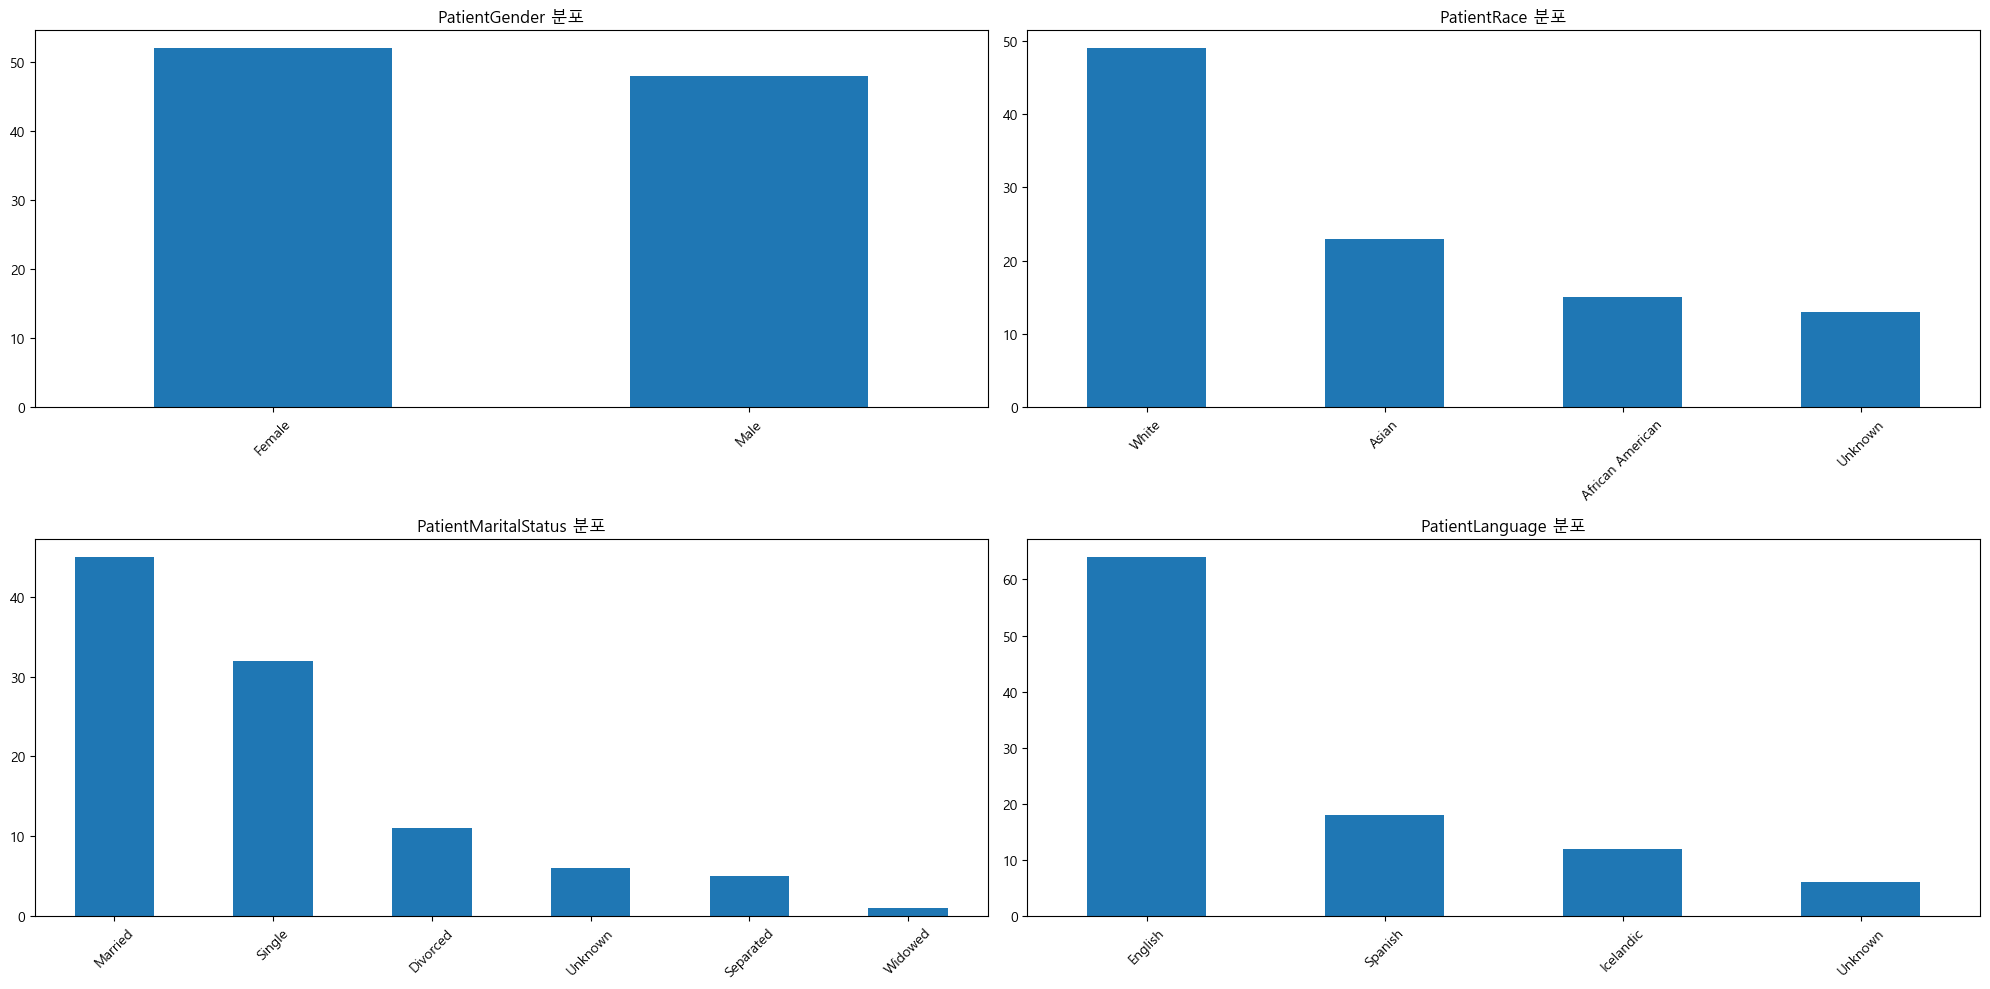

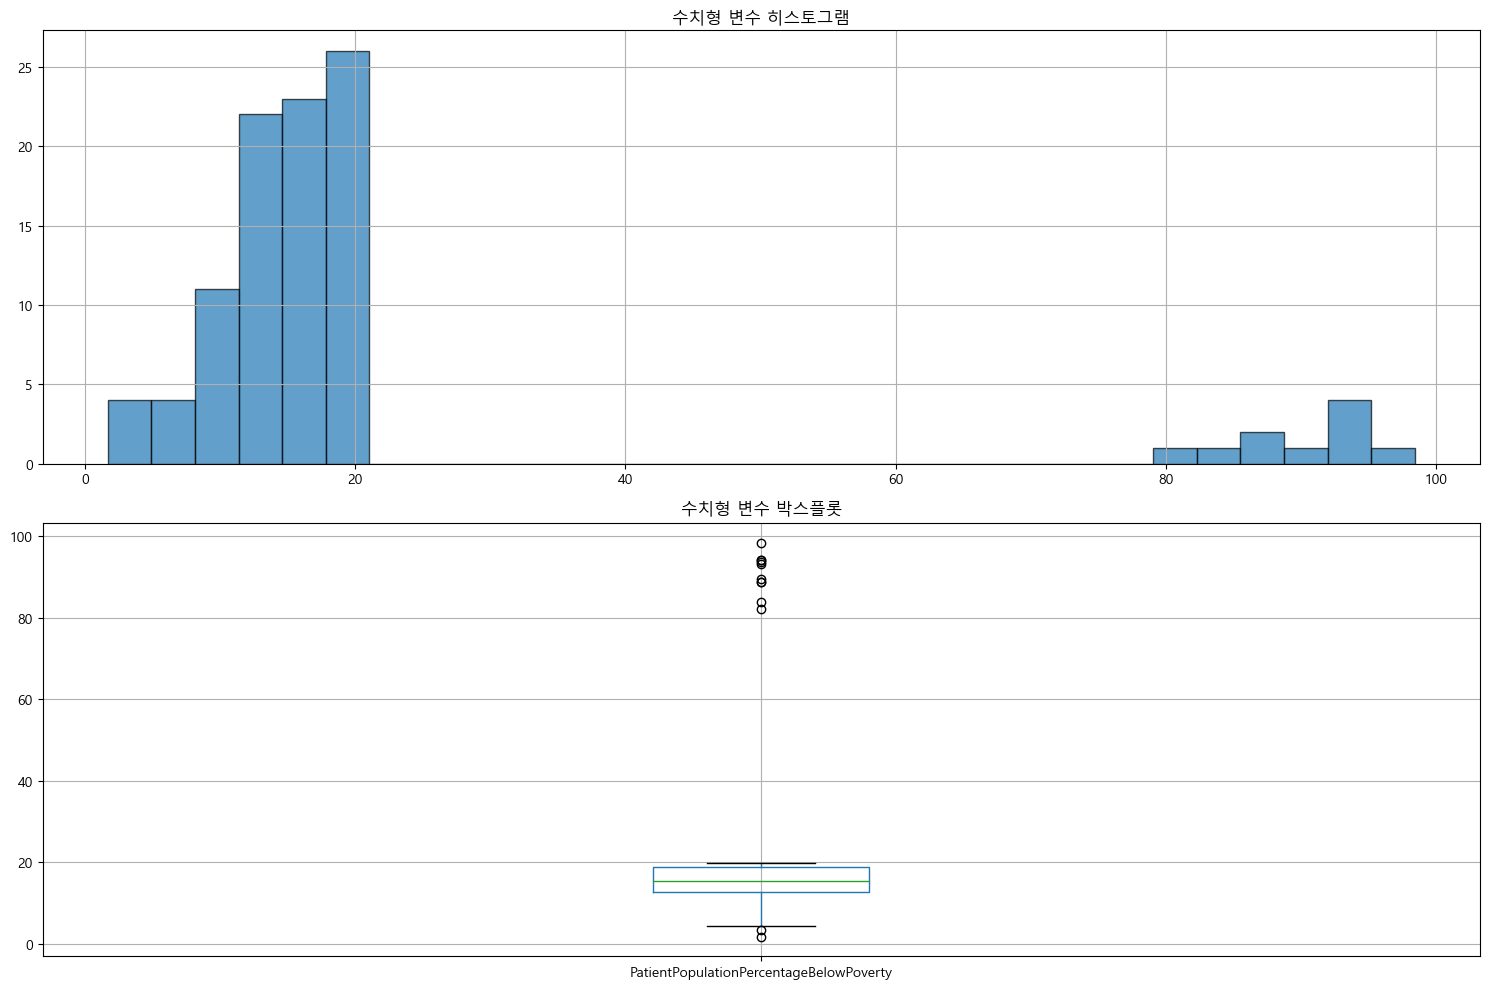

=============== 단변수 분포 요약 ===============

PatientGender:
Female    52
Male      48
Name: PatientGender, dtype: int64

PatientRace:
White               49
Asian               23
African American    15
Unknown             13
Name: PatientRace, dtype: int64

PatientMaritalStatus:
Married      45
Single       32
Divorced     11
Unknown       6
Separated     5
Widowed       1
Name: PatientMaritalStatus, dtype: int64

PatientLanguage:
English      64
Spanish      18
Icelandic    12
Unknown       6
Name: PatientLanguage, dtype: int64

PatientPopulationPercentageBelowPoverty:
count    100.000000
mean      22.102500
std       23.327656
min        1.700000
25%       12.702500
50%       15.435000
75%       18.687500
max       98.400000
Name: PatientPopulationPercentageBelowPoverty, dtype: float64


In [5]:
# ---------------------------
# Patient EDA (원본 함수 재구성)
# ---------------------------
def safe_univariate_eda(df, exclude_cols=['PatientID']):
    """원본과 동일한 단변수 EDA (플롯 + 텍스트)"""
    exclude_cols = set(exclude_cols)
    all_cols = [col for col in df.columns if col not in exclude_cols]
    cat_cols = [col for col in df.select_dtypes(include=['category', 'object']).columns if col not in exclude_cols]
    num_cols = [col for col in df.select_dtypes(include=['number']).columns if col not in exclude_cols]

    print(f"📊 분석 대상 (총 {len(all_cols)}개 컬럼):")
    print(f"  범주형 ({len(cat_cols)}개): {cat_cols}")
    print(f"  수치형 ({len(num_cols)}개): {num_cols}")

    # 범주형 플롯 (원본과 유사)
    if cat_cols:
        n_cats = len(cat_cols)
        ncols = max(2, (n_cats + 1)//2)
        fig, axes = plt.subplots(2, ncols, figsize=(20, 10))
        axes = axes.flatten()
        for i, col in enumerate(cat_cols):
            if i < len(axes):
                df[col].value_counts().plot.bar(ax=axes[i], rot=45)
                axes[i].set_title(f'{col} 분포')
                axes[i].tick_params(axis='x', rotation=45)
        for i in range(len(cat_cols), len(axes)):
            fig.delaxes(axes[i])
        plt.tight_layout()
        plt.show()

    # 수치형 플롯 (히스토, 박스)
    if num_cols:
        fig, axes = plt.subplots(2, 1, figsize=(15, 10))
        df[num_cols].hist(ax=axes[0], bins=30, edgecolor='black', alpha=0.7)
        axes[0].set_title('수치형 변수 히스토그램')
        df.boxplot(column=num_cols, ax=axes[1])
        axes[1].set_title('수치형 변수 박스플롯')
        plt.tight_layout()
        plt.show()
        
    # 텍스트 요약
    print("=============== 단변수 분포 요약 ===============")
    for col in cat_cols:
        print(f"\n{col}:")
        print(df[col].value_counts())
    for col in num_cols:
        print(f"\n{col}:")
        print(df[col].describe())

print("=== df_PCPT 단변수 분석 (PatientID 제외) ===")
safe_univariate_eda(df_PCPT)


    - 이변량 분석

=== df_PCPT 최종 3개 조합 이변량 분석 ===
🎯 핵심 3개 이변량 분석 (인종×언어 포함)

--- 1. 성별 × 결혼상태 ---


<Figure size 1200x600 with 0 Axes>

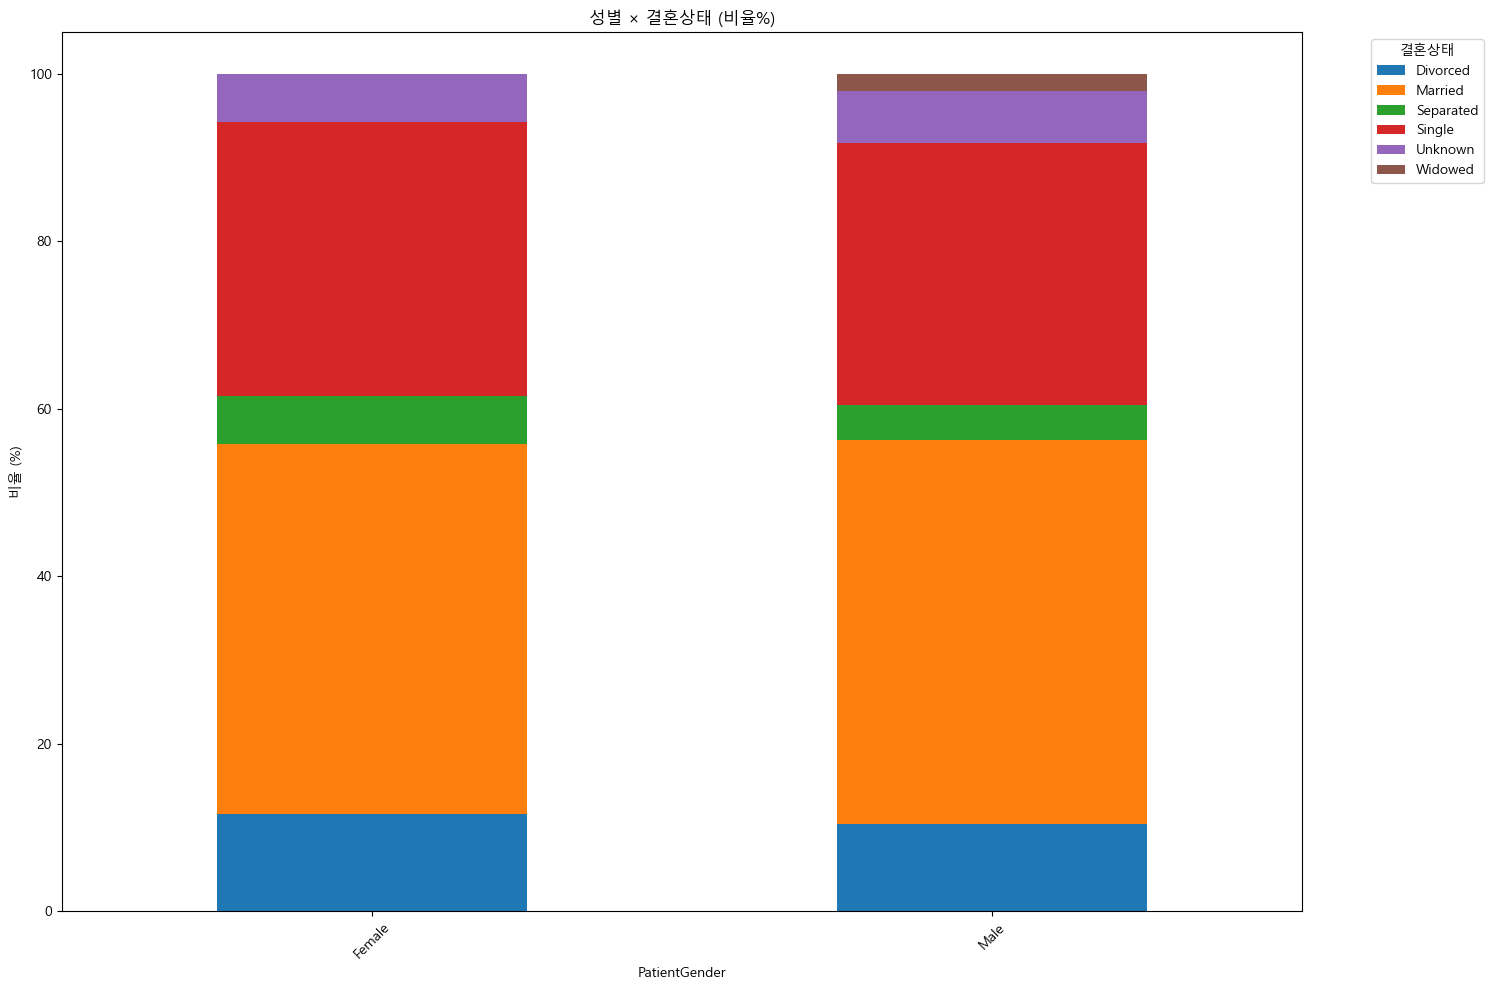

PatientMaritalStatus  Divorced  Married  Separated  Single  Unknown  Widowed
PatientGender                                                               
Female                    0.12     0.44       0.06    0.33     0.06     0.00
Male                      0.10     0.46       0.04    0.31     0.06     0.02

--- 2. 인종 × 언어 ---


<Figure size 1200x600 with 0 Axes>

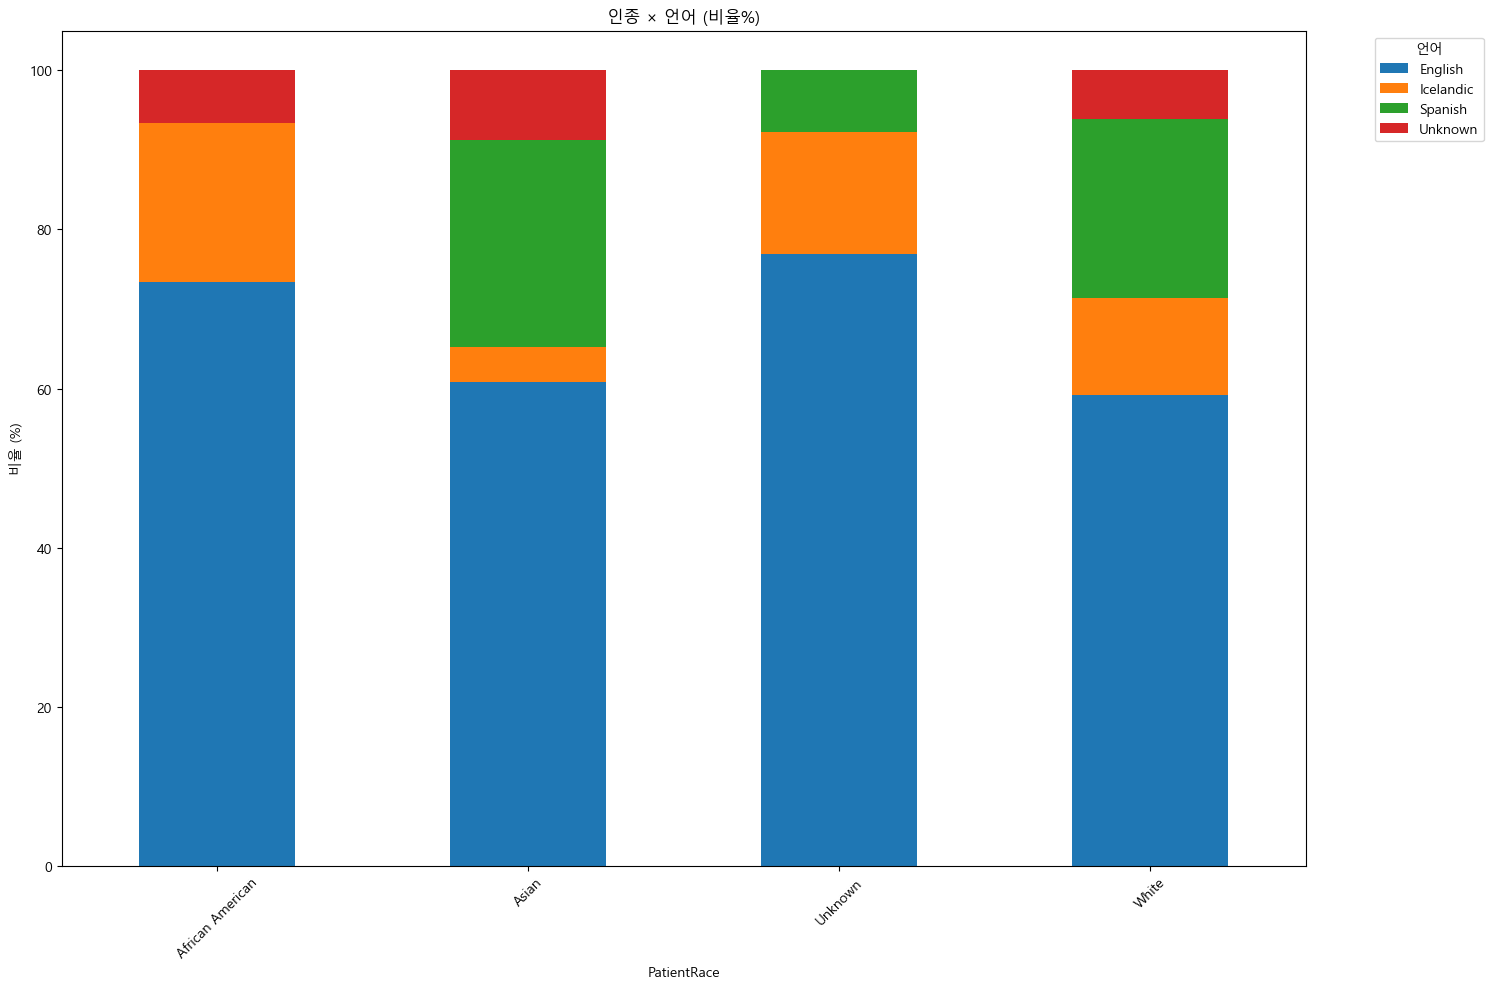

PatientLanguage   English  Icelandic  Spanish  Unknown
PatientRace                                           
African American     0.73       0.20     0.00     0.07
Asian                0.61       0.04     0.26     0.09
Unknown              0.77       0.15     0.08     0.00
White                0.59       0.12     0.22     0.06

--- 3. 빈곤율 × 인종/언어 (1by2 Stripplot) ---


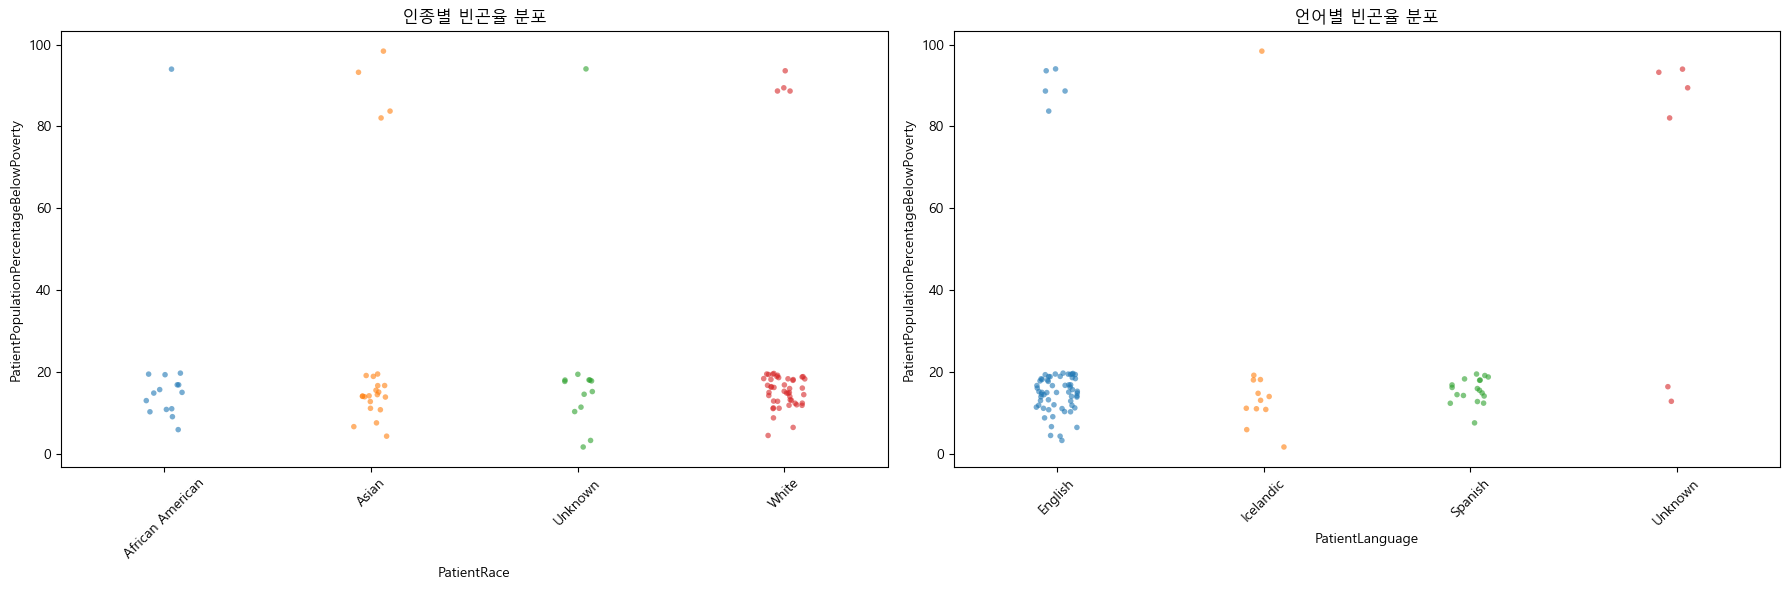

인종별 빈곤율:
                   mean  median  count
PatientRace                           
African American  19.49   15.04     15
Asian             26.84   14.49     23
Unknown           19.99   17.72     13
White             21.24   16.09     49

언어별 빈곤율:
                  mean  median  count
PatientLanguage                      
English          20.41   15.28     64
Icelandic        19.71   13.56     12
Spanish          15.53   15.77     18
Unknown          64.67   85.76      6


In [6]:
def focused_bivariate_eda_final(df):
    """원본의 3개 조합 이변량 분석을 동일하게 재현"""
    print("🎯 핵심 3개 이변량 분석 (인종×언어 포함)")
    # 1. 성별 × 결혼상태
    print("\n--- 1. 성별 × 결혼상태 ---")
    plt.figure(figsize=(12, 6))
    ct = pd.crosstab(df['PatientGender'], df['PatientMaritalStatus'], normalize='index') * 100
    ct.plot.bar(stacked=True)
    plt.title('성별 × 결혼상태 (비율%)')
    plt.ylabel('비율 (%)')
    plt.xticks(rotation=45)
    plt.legend(title='결혼상태', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    print(pd.crosstab(df['PatientGender'], df['PatientMaritalStatus'], normalize='index').round(2))

    # 2. 인종 × 언어
    print("\n--- 2. 인종 × 언어 ---")
    plt.figure(figsize=(12, 6))
    ct2 = pd.crosstab(df['PatientRace'], df['PatientLanguage'], normalize='index') * 100
    ct2.plot.bar(stacked=True)
    plt.title('인종 × 언어 (비율%)')
    plt.ylabel('비율 (%)')
    plt.xticks(rotation=45)
    plt.legend(title='언어', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    print(pd.crosstab(df['PatientRace'], df['PatientLanguage'], normalize='index').round(2))

    # 3. 빈곤율 × 인종/언어 (stripplot 1by2)
    print("\n--- 3. 빈곤율 × 인종/언어 (1by2 Stripplot) ---")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    sns.stripplot(data=df, x='PatientRace', y='PatientPopulationPercentageBelowPoverty', alpha=0.6, size=4, ax=ax1)
    ax1.set_title('인종별 빈곤율 분포')
    ax1.tick_params(axis='x', rotation=45)
    sns.stripplot(data=df, x='PatientLanguage', y='PatientPopulationPercentageBelowPoverty', alpha=0.6, size=4, ax=ax2)
    ax2.set_title('언어별 빈곤율 분포')
    ax2.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
    print("인종별 빈곤율:")
    print(df.groupby('PatientRace')['PatientPopulationPercentageBelowPoverty'].agg(['mean','median','count']).round(2))
    print("\n언어별 빈곤율:")
    print(df.groupby('PatientLanguage')['PatientPopulationPercentageBelowPoverty'].agg(['mean','median','count']).round(2))

print("=== df_PCPT 최종 3개 조합 이변량 분석 ===")
focused_bivariate_eda_final(df_PCPT)

## Admission EDA

=== df_ACPT LOS 업데이트 ===
✅ df_ACPT 업데이트 완료! (LOS만 추가)
입원 건수: 372건 | 환자 수: 100명
평균 LOS: 11.07일

=== 입원 EDA 실행 (category 완벽 대응) ===


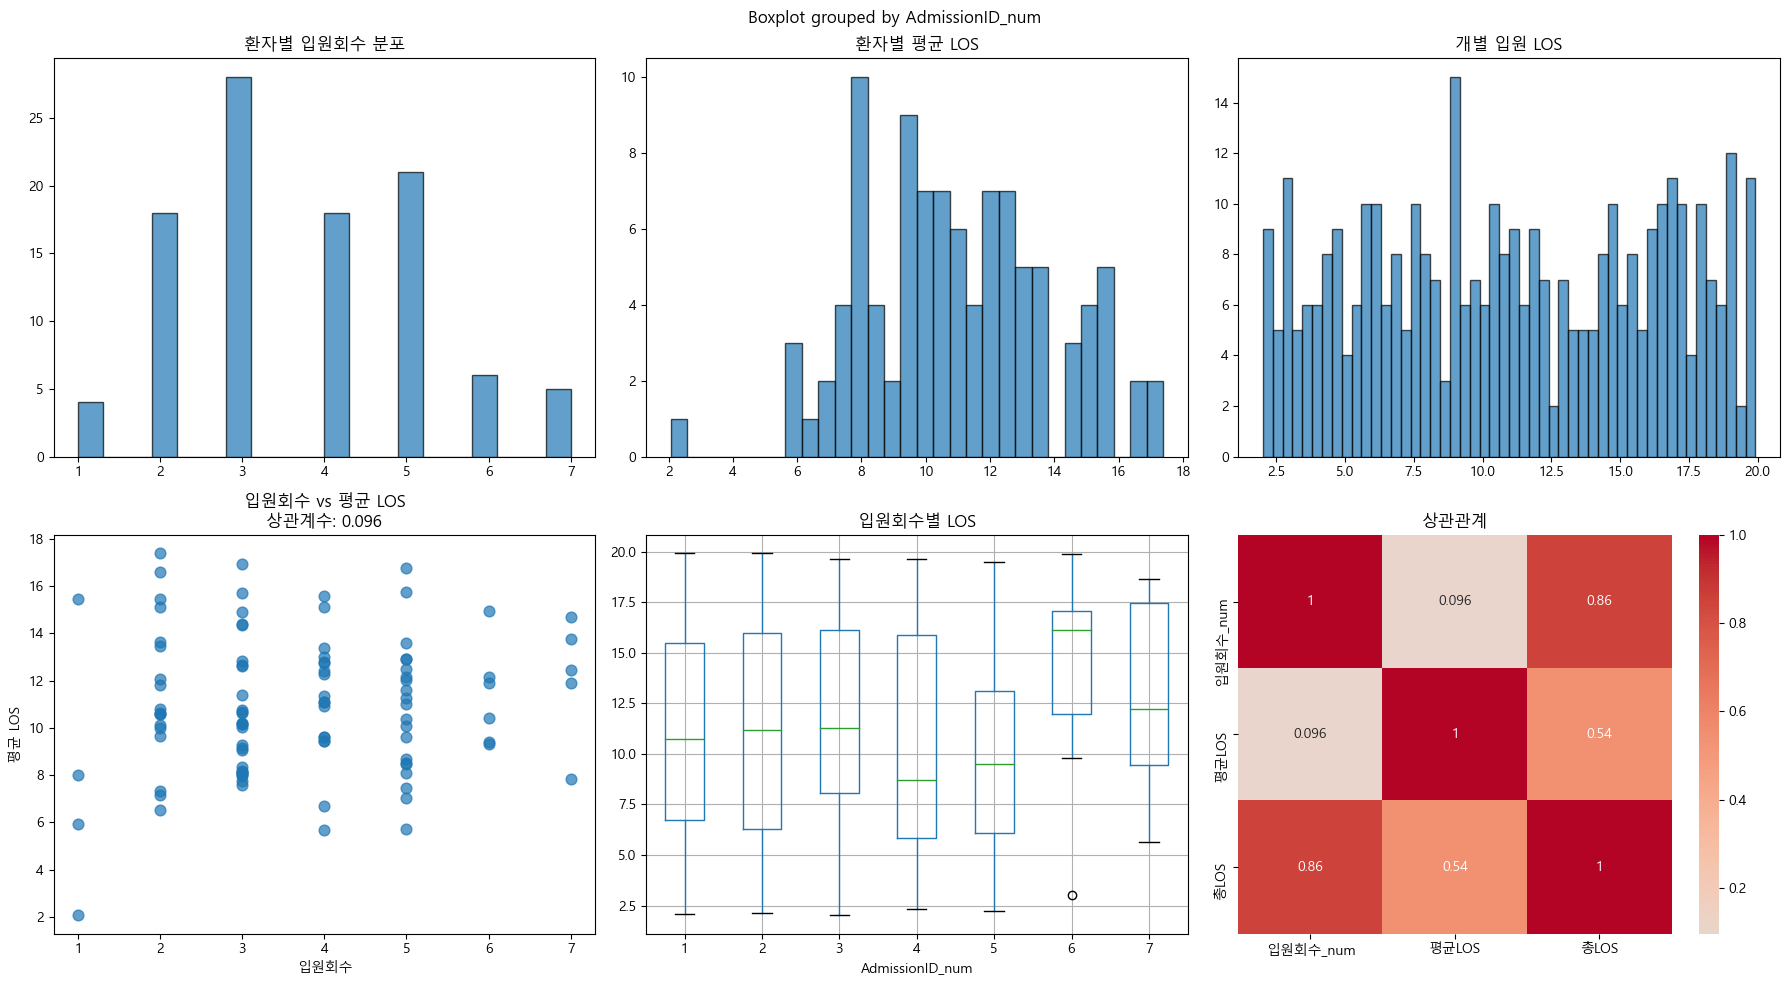

📊 상관계수 (입원회수-평균LOS): 0.096

🎯 입원 데이터 분석 요약
총 입원 건수: 372건
환자 수: 100명
최대 입원회수: 7회
평균 LOS: 11.07일
재입원 환자: 96.0%


In [7]:
# ---------------------------
# Admission EDA (LOS 계산 포함) - 원본 로직 유지
# ---------------------------
def update_df_ACPT_los(df_ACPT):
    df = df_ACPT.copy()
    df['AdmissionStartDate'] = pd.to_datetime(df['AdmissionStartDate'], errors='coerce')
    df['AdmissionEndDate'] = pd.to_datetime(df['AdmissionEndDate'], errors='coerce')
    df['LOS_days'] = (df['AdmissionEndDate'] - df['AdmissionStartDate']).dt.total_seconds() / (24*3600)
    df['입원_연도'] = df['AdmissionStartDate'].dt.year
    df['입원_월'] = df['AdmissionStartDate'].dt.month
    df_clean = df[(df['LOS_days'] > 0) & (df['LOS_days'] < 365)].copy()
    # 원본 data_frames 업데이트 (원본 코드와 동일 행동)
    data_frames['AdmissionsCorePopulatedTable'] = df_clean
    print(f"✅ df_ACPT 업데이트 완료! (LOS만 추가)")
    print(f"입원 건수: {len(df_clean):,}건 | 환자 수: {df_clean['PatientID'].nunique():,}명")
    print(f"평균 LOS: {df_clean['LOS_days'].mean():.2f}일")
    return df_clean

def admission_eda(df_ACPT):
    df = df_ACPT.copy()
    # category -> int (plot 용)
    df_plot = df.copy()
    try:
        df_plot['AdmissionID_num'] = df_plot['AdmissionID'].astype(int)
    except Exception:
        # cat이지만 숫자형 변환이 실패하면 범주별 코드 사용
        df_plot['AdmissionID_num'] = pd.Categorical(df_plot['AdmissionID']).codes

    # 환자별 집계
    patient_summary = df.groupby('PatientID').agg({
        'AdmissionID': 'max',
        'LOS_days': ['mean', 'sum']
    }).round(2)
    patient_summary.columns = ['입원회수','평균LOS','총LOS']
    patient_summary['입원회수_num'] = patient_summary['입원회수'].astype(int)

    # 6개 그래프 (원본 그대로)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    axes[0,0].hist(patient_summary['입원회수_num'], bins=20, edgecolor='black', alpha=0.7)
    axes[0,0].set_title('환자별 입원회수 분포')

    axes[0,1].hist(patient_summary['평균LOS'], bins=30, edgecolor='black', alpha=0.7)
    axes[0,1].set_title('환자별 평균 LOS')

    axes[0,2].hist(df['LOS_days'], bins=50, edgecolor='black', alpha=0.7)
    axes[0,2].set_title('개별 입원 LOS')

    corr = patient_summary['입원회수_num'].corr(patient_summary['평균LOS'])
    axes[1,0].scatter(patient_summary['입원회수_num'], patient_summary['평균LOS'], alpha=0.7, s=60)
    axes[1,0].set_title(f'입원회수 vs 평균 LOS\n상관계수: {corr:.3f}')
    axes[1,0].set_xlabel('입원회수'); axes[1,0].set_ylabel('평균 LOS')

    try:
        df_plot.boxplot(column='LOS_days', by='AdmissionID_num', ax=axes[1,1])
        axes[1,1].set_title('입원회수별 LOS')
    except Exception:
        axes[1,1].text(0.5, 0.5, '박스플롯 생성 실패', ha='center')

    corr_df = patient_summary[['입원회수_num','평균LOS','총LOS']].dropna()
    sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', center=0, ax=axes[1,2])
    axes[1,2].set_title('상관관계')

    plt.tight_layout()
    plt.show()

    print(f"📊 상관계수 (입원회수-평균LOS): {corr:.3f}")
    return patient_summary

print("=== df_ACPT LOS 업데이트 ===")
df_ACPT = update_df_ACPT_los(df_ACPT)

print("\n=== 입원 EDA 실행 (category 완벽 대응) ===")
patient_summary = admission_eda(df_ACPT)

print("\n" + "="*70)
print("🎯 입원 데이터 분석 요약")
print("="*70)
print(f"총 입원 건수: {len(df_ACPT):,}건")
print(f"환자 수: {df_ACPT['PatientID'].nunique():,}명")
try:
    print(f"최대 입원회수: {df_ACPT['AdmissionID'].astype(int).max():,}회")
except Exception:
    print("최대 입원회수: (AdmissionID 숫자 변환 불가)")
print(f"평균 LOS: {df_ACPT['LOS_days'].mean():.2f}일")
print(f"재입원 환자: {(df_ACPT.groupby('PatientID')['AdmissionID'].max().astype(int) > 1).mean()*100:.1f}%")

## Diagmosis EDA

In [8]:
def diagnosis_eda(df_ADCPT):
    df = df_ADCPT.copy()
    print("🏥 Diagnosis EDA (df_ADCPT only)")
    
    df['AdmissionID_num'] = df['AdmissionID'].astype(int)

    # ① 진단 빈도
    print("\n① 진단 빈도 Top 10 (Admission 기준)")
    dx_freq = df['PrimaryDiagnosisCode'].value_counts()
    print(dx_freq.head(10))

    # ② 진단 코드 중복도 요약
    total_dx = len(df)
    unique_dx = df['PrimaryDiagnosisCode'].nunique()
    uniqueness_ratio = unique_dx / total_dx

    print("\n② 진단 코드 중복도 요약")
    print(f"- 전체 진단 건수: {total_dx}")
    print(f"- 고유 진단 코드 수: {unique_dx}")
    print(f"- 고유 진단 비율: {uniqueness_ratio:.2%}")

    if uniqueness_ratio > 0.8:
        print("✅ 진단 코드 중복이 매우 낮아, 개별 케이스 중심 데이터 특성을 가짐")
    elif uniqueness_ratio > 0.5:
        print("ℹ️ 일부 중복은 있으나, 진단 다양성이 높은 편")
    else:
        print("⚠️ 특정 진단 코드에 빈도가 집중됨")

    # ③ 코드-설명 매핑 검증
    code_desc_check = df.groupby('PrimaryDiagnosisCode')['PrimaryDiagnosisDescription'].nunique()
    print("\n③ 진단 코드-설명 1:1 매핑 여부")
    print("✅ 정상" if (code_desc_check == 1).all() else "❌ 불일치 존재")
    
diagnosis_eda(df_ADCPT)

🏥 Diagnosis EDA (df_ADCPT only)

① 진단 빈도 Top 10 (Admission 기준)
Z22.31     3
E30        2
K57.5      2
J66.1      2
E09.62     2
C40.11     2
I79.0      2
M02.352    2
C18.3      2
C94.32     2
Name: PrimaryDiagnosisCode, dtype: int64

② 진단 코드 중복도 요약
- 전체 진단 건수: 372
- 고유 진단 코드 수: 349
- 고유 진단 비율: 93.82%
✅ 진단 코드 중복이 매우 낮아, 개별 케이스 중심 데이터 특성을 가짐

③ 진단 코드-설명 1:1 매핑 여부
✅ 정상


## Labs EDA

🧪 실험실 검사 완전 분석 + 계절성 (기상청 기준)
총 검사: 111,483건 | 기간: 1941~2013

📊 Top 10 검사 품목:
CBC: NEUTROPHILS                 3224
URINALYSIS: WHITE BLOOD CELLS    3218
METABOLIC: CARBON DIOXIDE        3218
CBC: HEMATOCRIT                  3211
CBC: ABSOLUTE NEUTROPHILS        3210
CBC: WHITE BLOOD CELL COUNT      3209
METABOLIC: SODIUM                3207
CBC: MCHC                        3202
METABOLIC: ALBUMIN               3202
METABOLIC: GLUCOSE               3202
Name: LabName, dtype: int64

👥 환자당 평균 검사: 1114.8개 | 검사왕: 2760개

📅 연도별 패턴:
      검사건수  검사종류
Year            
1941   243    35
1942   306    35
1944   352    35
1945   867    35
1947   208    35
1948   407    35
1949   510    35
1950   189    35
1951   153    35
1952    76    34
1953   690    35
1954   315    35
1956   817    35
1959   937    35
1960   384    35
1961   289    35
1962   899    35
1964   693    35
1965  1029    35
1966   162    35
1967  1379    35
1968  1221    35
1970  1429    35
1971   457    35
1972   146    35
1973   78

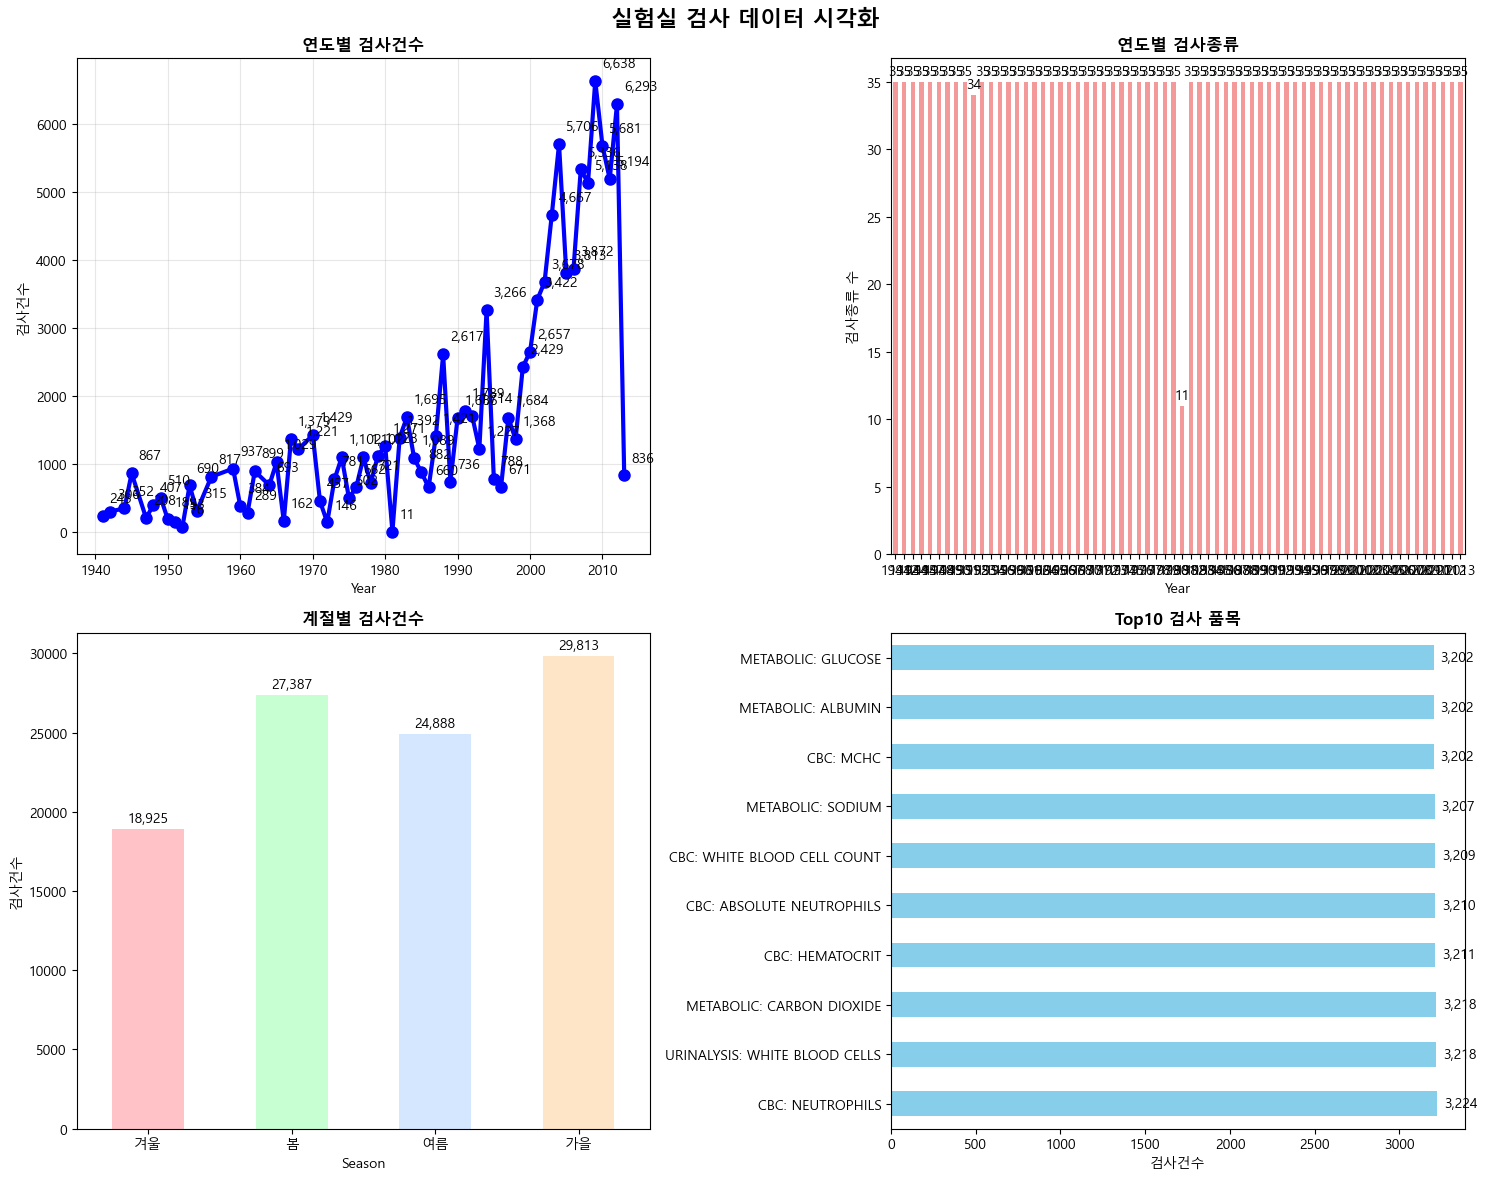


✅ 원본 데이터 업데이트 완료
📅 계절 기준: 겨울(12-2월), 봄(3-5월), 여름(6-8월), 가을(9-11월)


In [9]:
# ---------------------------
# Labs EDA (원본 lab_complete_eda_v4 동일 동작)
# ---------------------------
def lab_complete_eda_v4(df_lab):
    df = df_lab.copy()
    df['LabDateTime'] = pd.to_datetime(df['LabDateTime'], errors='coerce')
    df['Year'] = df['LabDateTime'].dt.year
    df['Month'] = df['LabDateTime'].dt.month
    df['Season'] = pd.cut(df['Month'], bins=[0,3,6,9,12], labels=['겨울','봄','여름','가을'], right=False)
    for col in ['PatientID','AdmissionID','LabName']:
        if col in df.columns:
            df[col] = df[col].astype(str)
    print("🧪 실험실 검사 완전 분석 + 계절성 (기상청 기준)")
    print(f"총 검사: {len(df):,}건 | 기간: {df['Year'].min()}~{df['Year'].max()}")
    top_labs = df['LabName'].value_counts().head(10)
    print("\n📊 Top 10 검사 품목:")
    print(top_labs)
    patient_lab_cnt = df.groupby('PatientID').size()
    avg_tests = patient_lab_cnt.mean(); max_tests = patient_lab_cnt.max()
    print(f"\n👥 환자당 평균 검사: {avg_tests:.1f}개 | 검사왕: {max_tests}개")
    yearly_stats = df.groupby('Year').agg({'LabName':['size','nunique']}).round(0)
    yearly_stats.columns = ['검사건수','검사종류']
    print("\n📅 연도별 패턴:")
    print(yearly_stats)
    if len(yearly_stats) > 1:
        growth_rate = ((yearly_stats['검사종류'].iloc[-1] / yearly_stats['검사종류'].iloc[0]) - 1) * 100
        print(f"   검사종류 증가율: +{growth_rate:.0f}%")
    season_stats = df.groupby('Season').agg({'LabName':['size','nunique']}).round(0).fillna(0)
    season_stats.columns = ['검사건수','검사종류']
    print("\n❄️ 계절별 패턴 (기상청 기준: 가을9-11월, 겨울12-2월):")
    print(season_stats)
    # 시각화 (원본과 동일)
    fig, axes = plt.subplots(2, 2, figsize=(15,12))
    fig.suptitle('실험실 검사 데이터 시각화', fontsize=16, fontweight='bold')
    yearly_stats['검사건수'].plot(ax=axes[0,0], marker='o', linewidth=3, markersize=8, color='blue')
    axes[0,0].set_title('연도별 검사건수', fontweight='bold', fontsize=12); axes[0,0].set_ylabel('검사건수'); axes[0,0].grid(True, alpha=0.3)
    for i, v in enumerate(yearly_stats['검사건수']): axes[0,0].annotate(f'{v:,.0f}', (yearly_stats.index[i], v), xytext=(5, 10), textcoords='offset points', fontsize=10)
    yearly_stats['검사종류'].plot(kind='bar', ax=axes[0,1], color='lightcoral', alpha=0.8)
    axes[0,1].set_title('연도별 검사종류', fontweight='bold', fontsize=12); axes[0,1].set_ylabel('검사종류 수'); axes[0,1].tick_params(axis='x', rotation=0)
    for i, v in enumerate(yearly_stats['검사종류']): axes[0,1].annotate(f'{v:.0f}', (i, v), xytext=(0, 5), textcoords='offset points', ha='center', fontsize=10)
    season_order = ['겨울','봄','여름','가을']
    season_colors = ['#FFB3BA', '#BAFFC9', '#CBE0FF', '#FFDFBA']
    season_stats.loc[season_order, '검사건수'].plot(kind='bar', ax=axes[1,0], color=season_colors, alpha=0.8)
    axes[1,0].set_title('계절별 검사건수', fontweight='bold', fontsize=12); axes[1,0].set_ylabel('검사건수'); axes[1,0].tick_params(axis='x', rotation=0)
    for i, v in enumerate(season_stats.loc[season_order, '검사건수']): axes[1,0].annotate(f'{v:,.0f}', (i, v), xytext=(0, 5), textcoords='offset points', ha='center', fontsize=10)
    top_labs.head(10).plot(kind='barh', ax=axes[1,1], color='skyblue')
    axes[1,1].set_title('Top10 검사 품목', fontweight='bold', fontsize=12); axes[1,1].set_xlabel('검사건수')
    for i, v in enumerate(top_labs.head(10)): axes[1,1].annotate(f'{v:,.0f}', (v, i), xytext=(5, 0), textcoords='offset points', va='center', fontsize=10)
    plt.tight_layout()
    plt.show()
    print("\n✅ 원본 데이터 업데이트 완료")
    print("📅 계절 기준: 겨울(12-2월), 봄(3-5월), 여름(6-8월), 가을(9-11월)")

lab_complete_eda_v4(df_LCPT)

# 데이터셋 병합
## 환자x입원 ID를 고유 행으로 두고 개인정보와 일시를 붙이며
## 검진 항목을 열로 늘어뜨리는 구조

In [10]:
# 검사명(LabName)별로 고유한 단위(LabUnits)가 몇 개인지 확인
unit_counts = df_LCPT.groupby('LabName')['LabUnits'].nunique()

# 단위가 2개 이상인 검사 항목만 추출
inconsistent_units = unit_counts[unit_counts > 1]

if inconsistent_units.empty:
    print("✅ 모든 검사의 단위가 일관적입니다.")
else:
    print("⚠️ 단위가 일관되지 않은 검사 항목 발견:")
    for lab in inconsistent_units.index:
        units = df_LCPT[df_LCPT['LabName'] == lab]['LabUnits'].unique()
        print(f"- {lab}: {list(units)}")


        
# def unify_units(df):
#     # 복사본 생성
#     df_clean = df.copy()
    
#     # ---------------------------------------------------------
#     # 예시: 특정 검사(예: 'Glucose')의 단위가 분산되어 있을 때 변환 로직
#     # 실제 데이터의 단위 확인 후 아래 mapping을 수정해서 사용하세요.
#     # ---------------------------------------------------------
    
#     # 예: g/dL를 mg/dL로 통일하는 경우 (x1000)
#     # mask = (df_clean['LabName'] == 'Glucose') & (df_clean['LabUnits'] == 'g/dL')
#     # df_clean.loc[mask, 'LabValue'] = df_clean.loc[mask, 'LabValue'] * 1000
#     # df_clean.loc[mask, 'LabUnits'] = 'mg/dL'
    
#     # 만약 단순히 대소문자나 오타 문제라면 (예: 'mg/dl' -> 'mg/dL')
#     df_clean['LabUnits'] = df_clean['LabUnits'].str.strip() # 공백 제거
    
#     # 단위 확인 후 비정상적으로 튀는 단위를 가진 행은 제거하거나 보정하는 처리가 필요합니다.
#     return df_clean

# # 단위 통일 적용
# df_LCPT_unified = unify_units(df_LCPT)


✅ 모든 검사의 단위가 일관적입니다.


# 정리 버전

# EMR 데이터 기반 입원 기간(LOS) 예측 및 환자 페노타입 분석

## 1. 분석 개요
본 프로젝트는 EMR(Electronic Medical Record) 정형 데이터를 활용하여 환자의 검사 수치 패턴과 입원 기간(Length of Stay, LOS) 사이의 관계를 규명합니다.

### 주요 분석 단계
1. **Feature Engineering**: 시계열 검사 로우 데이터로부터 추이(Trend), 변동성(Std), 이상치 합계(Abnormal Sum) 도출
2. **Dimension Reduction**: PCA 및 t-SNE를 통한 고차원 데이터의 독립성 및 구조 시각화
3. **Clustering**: K-Means를 활용한 데이터 기반 환자 군집(Phenotype) 식별
4. **Modeling & XAI**: Random Forest를 이용한 LOS 예측 및 SHAP을 통한 모델의 의사결정 근거 해석

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import shap

# 1. 데이터 통합 전처리 및 파생 변수 생성 함수
def create_master_dataset_final(admissions, diagnoses, labs, patients):
    # 시간 계산을 위한 AdmissionStartDate 병합
    labs_with_start = pd.merge(
        labs, 
        admissions[['PatientID', 'AdmissionID', 'AdmissionStartDate']], 
        on=['PatientID', 'AdmissionID'], 
        how='left'
    )
    
    # HoursAfterAdmission 컬럼 생성
    labs_with_start['HoursAfterAdmission'] = (
        (labs_with_start['LabDateTime'] - labs_with_start['AdmissionStartDate']).dt.total_seconds() / 3600
    )
    labs = labs_with_start.drop(columns=['AdmissionStartDate'])

    # 환자 기본 정보 및 진단명 병합
    patient_admission = pd.merge(patients, admissions, on='PatientID', how='inner')
    patient_admission_diag = pd.merge(patient_admission, diagnoses, on=['PatientID', 'AdmissionID'], how='left')

    # Lab 데이터 이상치(IsAbnormal) 판별 (1.5 STD 기준)
    lab_stats = labs.groupby('LabName')['LabValue'].agg(['mean', 'std']).reset_index()
    lab_stats['upper'] = lab_stats['mean'] + 1.5 * lab_stats['std']
    lab_stats['lower'] = lab_stats['mean'] - 1.5 * lab_stats['std']
    
    labs = labs.merge(lab_stats[['LabName', 'upper', 'lower']], on='LabName', how='left')
    labs['IsAbnormal'] = ((labs['LabValue'] > labs['upper']) | (labs['LabValue'] < labs['lower'])).astype(int)

    # 입원 단위별 검사 지표 집계 (Trend 및 변동성 포함)
    labs = labs.sort_values(['AdmissionID', 'LabName', 'HoursAfterAdmission'])
    lab_agg = labs.groupby(['PatientID', 'AdmissionID', 'LabName']).agg(
        Lab_Mean=('LabValue', 'mean'),
        Lab_Std=('LabValue', 'std'),
        Abnormal_Sum=('IsAbnormal', 'sum'),
        First_Value=('LabValue', 'first'),
        Last_Value=('LabValue', 'last')
    ).reset_index()
    
    # 추이(Trend) 계산: 마지막 수치 - 처음 수치
    lab_agg['Lab_Trend'] = lab_agg['Last_Value'] - lab_agg['First_Value']

    # Wide 포맷으로 변환 (Feature Expansion)
    master_wide = lab_agg.pivot_table(
        index=['PatientID', 'AdmissionID'],
        columns='LabName',
        values=['Lab_Mean', 'Lab_Std', 'Abnormal_Sum', 'Lab_Trend']
    )
    master_wide.columns = [f"{col[0]}_{col[1]}" for col in master_wide.columns]
    master_wide = master_wide.reset_index()

    # 최종 데이터셋 병합 및 LOS/나이 계산
    final_dataset = pd.merge(patient_admission_diag, master_wide, on=['PatientID', 'AdmissionID'], how='inner')
    final_dataset['LOS_Days'] = (final_dataset['AdmissionEndDate'] - final_dataset['AdmissionStartDate']).dt.total_seconds() / 86400
    
    # 고차원 중증도 지표 추가
    abnormal_cols = [c for c in final_dataset.columns if 'Abnormal_Sum' in c]
    final_dataset['Total_Abnormal_Count'] = final_dataset[abnormal_cols].sum(axis=1)
    
    std_cols = [c for c in final_dataset.columns if 'Lab_Std' in c]
    final_dataset['Total_Lab_Variability'] = final_dataset[std_cols].mean(axis=1)

    return final_dataset

# 함수 실행 (df_ACPT, df_ADCPT, df_LCPT, df_PCPT가 로드된 상태여야 함)
df_final = create_master_dataset_final(df_ACPT, df_ADCPT, df_LCPT, df_PCPT)
print(f"최종 분석 데이터셋 구축 완료: {df_final.shape}")

최종 분석 데이터셋 구축 완료: (372, 158)


In [1]:
#!pip install shap

  Using cached packaging-25.0-py3-none-any.whl (66 kB)
  Attempting uninstall: packaging
    Found existing installation: packaging 20.7
    Uninstalling packaging-20.7:
      Successfully uninstalled packaging-20.7


## 2. 데이터 구조 탐색: 차원 축소 분석 (PCA & t-SNE)
- **Scree Plot**: 주성분들이 데이터의 분산을 얼마나 대변하는지 확인합니다.
- **t-SNE**: 선형 분석으로 잡기 어려운 데이터의 비선형적 군집 구조를 시각화합니다.
- 검진 수치 평균값 간 분산 구조와 환자 간 응집성을 확인하기 위해
PCA(선형 차원 축소)와 t-SNE(비선형 임베딩)를 적용하였다.

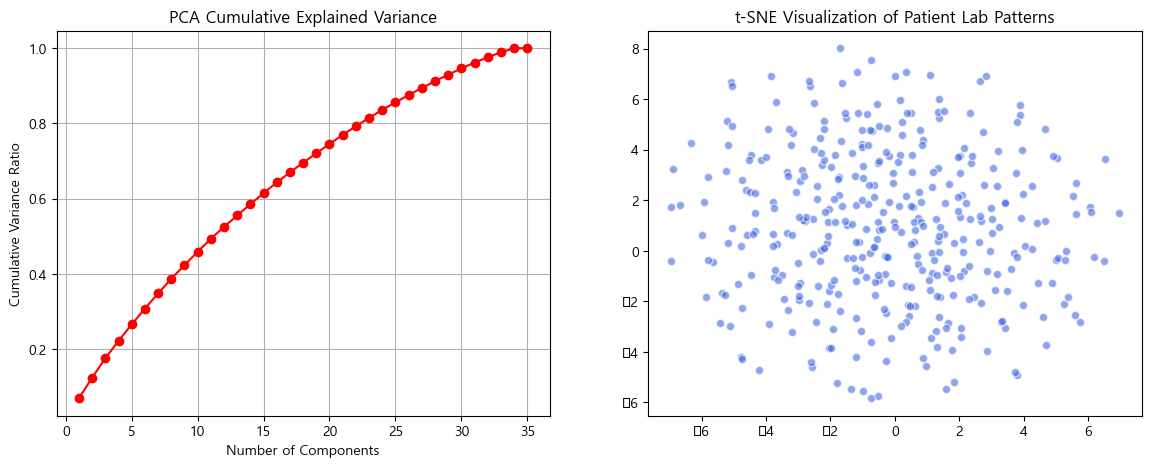

전체 변수 PC1 설명력: 0.0700
Top 5 변수 PC1 설명력: 0.2472


In [12]:
# 분석용 수치 피처 선택
lab_mean_cols = [c for c in df_final.columns if 'Lab_Mean' in c]
X_scaled = StandardScaler().fit_transform(df_final[lab_mean_cols].fillna(0))

# 1. PCA 실행
pca = PCA().fit(X_scaled)

plt.figure(figsize=(14, 5))

# PCA Scree Plot
plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), 'ro-')
plt.title('PCA Cumulative Explained Variance', fontsize=12)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Ratio')
plt.grid(True)

# 2. t-SNE 실행
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_res = tsne.fit_transform(X_scaled)

plt.subplot(1, 2, 2)
plt.scatter(tsne_res[:, 0], tsne_res[:, 1], alpha=0.6, c='royalblue', edgecolors='w')
plt.title('t-SNE Visualization of Patient Lab Patterns', fontsize=12)
plt.show()

# 3. Top 5 Feature PCA 분석 (설명력 극대화 확인)
top5_vars = df_final[lab_mean_cols].var().sort_values(ascending=False).head(5).index
X_top5 = StandardScaler().fit_transform(df_final[top5_vars].fillna(0))
pca_top5 = PCA(n_components=2)
X_pca_top5 = pca_top5.fit_transform(X_top5)

print(f"전체 변수 PC1 설명력: {pca.explained_variance_ratio_[0]:.4f}")
print(f"Top 5 변수 PCs 설명력: {pca_top5.explained_variance_ratio_[0]:.4f}")

검진 수치 패턴을 탐색하기 위해 PCA를 적용하여 분산을 주도하는 검사 항목을 확인하고, t-SNE를 통해 환자 간 국소적 패턴 존재 여부를 평가하였다. 그러나 PCA에서 개별 주성분의 설명력이 전반적으로 낮았으며, t-SNE 시각화에서도 샘플들이 특정 군집 없이 고르게 분포하는 양상을 보여, 검진 수치의 평균값만으로는 환자 특성을 구분할 수 있는 명확한 표현을 얻기 어려웠다.  
PCA에서는 상위 주성분의 설명력이 전반적으로 낮았고,
t-SNE에서도 환자군 간 명확한 군집 또는 국소적 응집 패턴은 관찰되지 않았다.

이에 따라, 차원 축소 결과가 실제 임상 변수와 어떤 관계를 가지는지를 확인하기 위해
상위 주성분과 환자 임상 속성 간의 정렬(alignment) 여부를 산점도를 통해 추가적으로 평가하였다.


In [17]:
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

pca_cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pca_cols, index=df_final.index)

df_final = pd.concat([df_final, df_pca], axis=1)


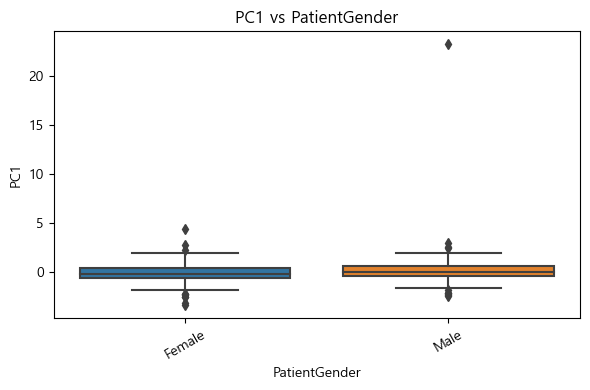

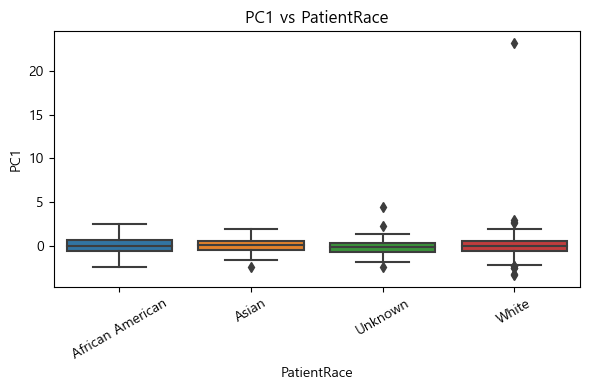

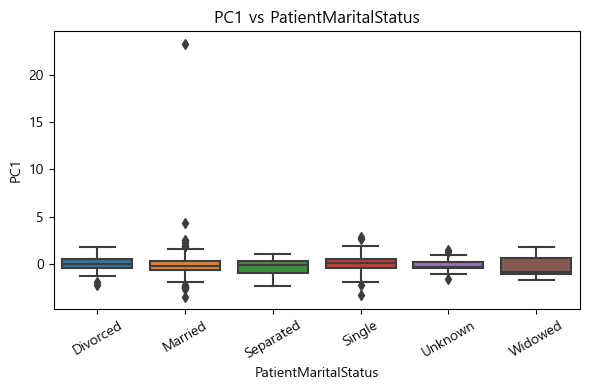

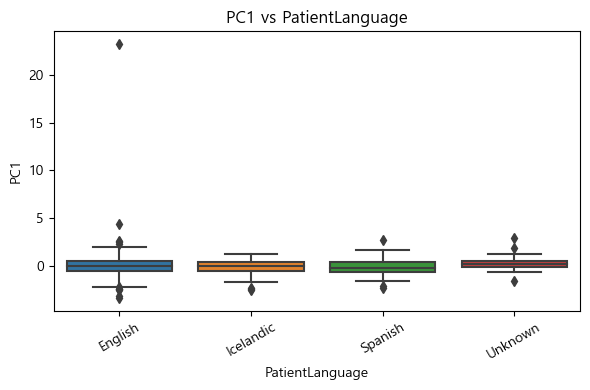

In [18]:


cat_cols = df_final.select_dtypes(include=['category']).columns

for col in cat_cols:
    if df_final[col].nunique() <= 6:
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=col, y='PC1', data=df_final)
        plt.title(f'PC1 vs {col}')
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()


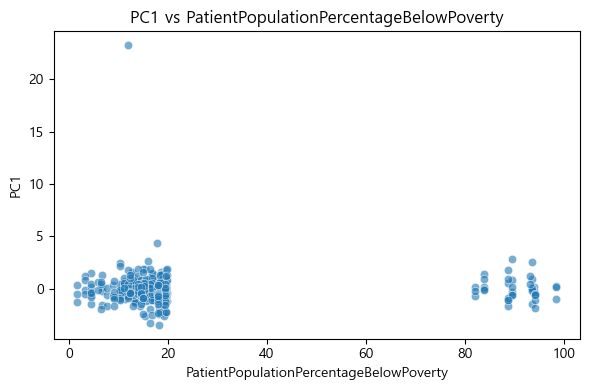

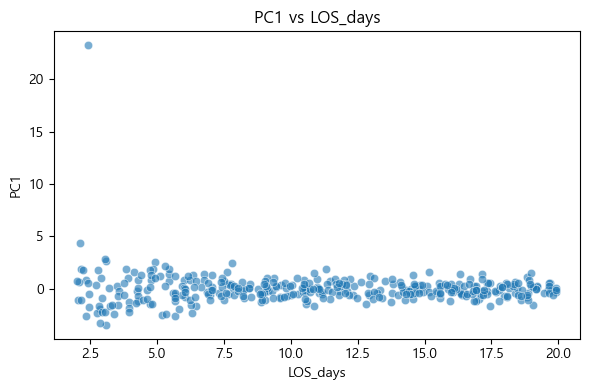

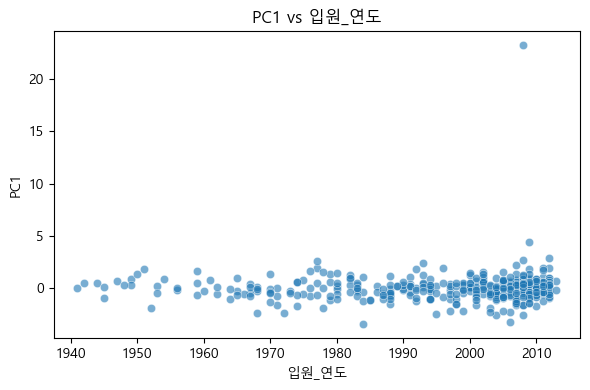

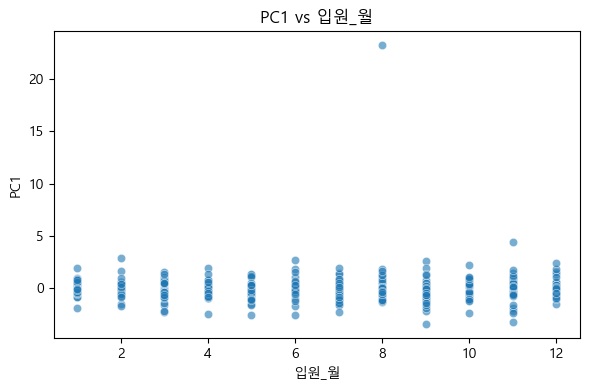

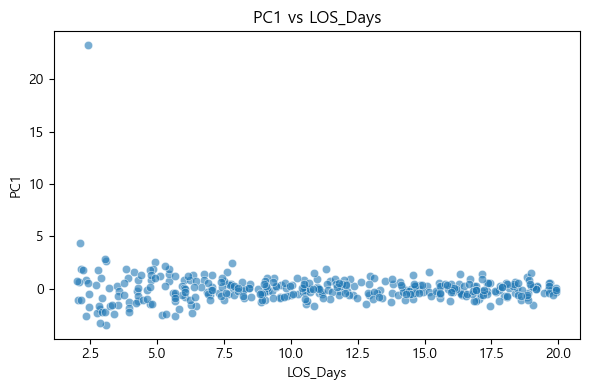

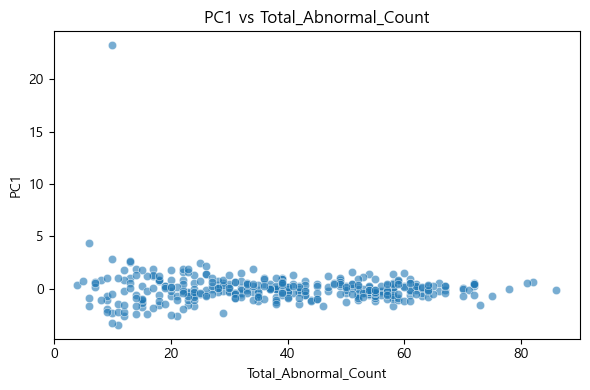

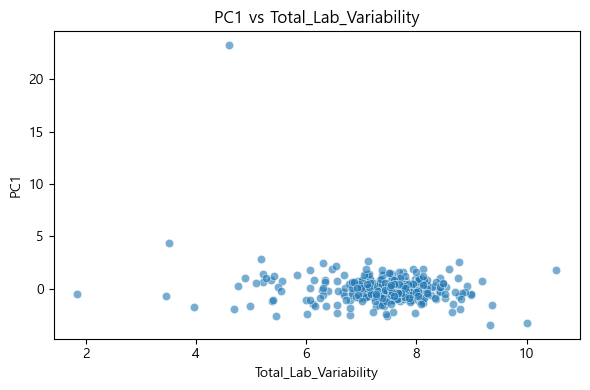

In [22]:
exclude_prefixes = ('Lab_', 'Abnormal_', 'PC')

num_cols = df_final.select_dtypes(include=['int64', 'float64']).columns

num_cols = [
    c for c in num_cols
    if not c.startswith(exclude_prefixes)
]



for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=col, y='PC1', data=df_final, alpha=0.6)
    plt.title(f'PC1 vs {col}')
    plt.tight_layout()
    plt.show()
    
    


그러나 다수의 환자 속성 변수에 대해 상위 주성분들은 거의 일정한 분포를 보였으며,
이는 주성분 축이 연령, 진단군, 재입원 여부 등 임상 변수들과
유의미한 선형 상관관계를 갖지 않음을 시사한다.  

  
  종합하면, 평균 검진 수치를 기반으로 한 차원 축소 및 주성분–임상 변수 간 정렬 분석에서
환자 임상 특성을 설명할 수 있는 유의미한 분산 축은 관찰되지 않았으며,
이는 단순 평균값에 기반한 선형 조합만으로는
환자 상태의 임상적 이질성을 충분히 포착하기 어렵다는 한계를 시사한다.
  

다수의 환자 속성 변수에 대해 PC1은 거의 일정한 값을 유지하였으며,
이는 PC1이 해당 변수들과 유의미한 선형 상관관계를 갖지 않음을 시사한다.

평균 검진 수치를 기반으로 수행한 차원 축소 분석 결과,
특정 검사가 환자의 임상적 특성이나 재입원 여부를 대표하는 주된 분산 축으로 작용하지 않았고,
이는 환자 상태를 설명하기 위해 단순 요약 통계(평균값)보다는
시간적 변화나 구조적 패턴을 포함한 보다 풍부한 정보 표현이 필요함을 시사한다.

In [21]:
df_final.dtypes

PatientID                                             object
PatientGender                                       category
PatientDateOfBirth                            datetime64[ns]
PatientRace                                         category
PatientMaritalStatus                                category
PatientLanguage                                     category
PatientPopulationPercentageBelowPoverty              float64
AdmissionID                                         category
AdmissionStartDate                            datetime64[ns]
AdmissionEndDate                              datetime64[ns]
LOS_days                                             float64
입원_연도                                                  int64
입원_월                                                   int64
PrimaryDiagnosisCode                                category
PrimaryDiagnosisDescription                           object
Abnormal_Sum_CBC: ABSOLUTE LYMPHOCYTES               float64
Abnormal_Sum_CBC: ABSOLU

## 3. 비지도 학습 기반 환자 군집화 (K-Means)
데이터 내의 유사한 검사 패턴을 가진 환자군을 스스로 분류합니다.

PCA와 t-SNE를 통해 검사 수치 평균 기반 표현의 한계를 확인한 이후, 환자 분포를 정량적으로 비교하기 위해 군집화를 수행하였다. 군집 분석은 차원 축소 결과를 정량적으로 재확인하기 위한 절차

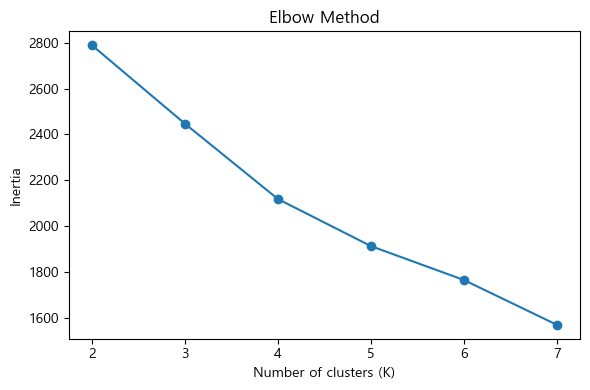

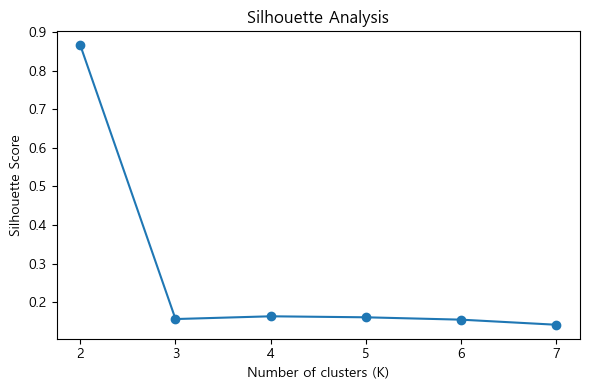

In [23]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertias = []
silhouettes = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

# Elbow plot
plt.figure(figsize=(6, 4))
plt.plot(K_range, inertias, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.tight_layout()
plt.show()

# Silhouette plot
plt.figure(figsize=(6, 4))
plt.plot(K_range, silhouettes, marker='o')
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.tight_layout()
plt.show()


차원 축소 결과에서 연속적인 분산 구조는 관찰되지 않았으나,  
평균 검진 수치 패턴에 기반한 이산적 하위 환자군 존재 가능성을 검토하기 위해  
PCA space에서 K-means 군집화를 수행하였다.  
군집 수에 따른 내부 응집도 및 검사 수치 분포를 함께 검토한 결과,  
임상적으로 명확히 구분되는 환자 하위 집단은 확인되지 않았다.  
  
    
K-means 군집화를 통해 잠재적 환자 하위군을 탐색했으나,
silhouette score는 K=2에서만 높게 나타났고
그 외 K에서는 의미 있는 군집 분리가 관찰되지 않았다.
이는 평균 검사 수치의 선형 결합만으로는
환자 임상 특성을 반영하는 자연 군집이 형성되지 않음을 시사한다.


## 4. 입원 기간(LOS) 예측 모델 및 SHAP 해석
검사 평균값뿐만 아니라 우리가 생성한 **Trend, Variability, Cluster** 정보를 모두 활용하여 모델링을 수행합니다.  

구조는 없지만, 특정 결과(입원기간)에 영향을 주는 요인은 있는가?

Model R2 Score: 0.9123
Mean Absolute Error: 1.26 days


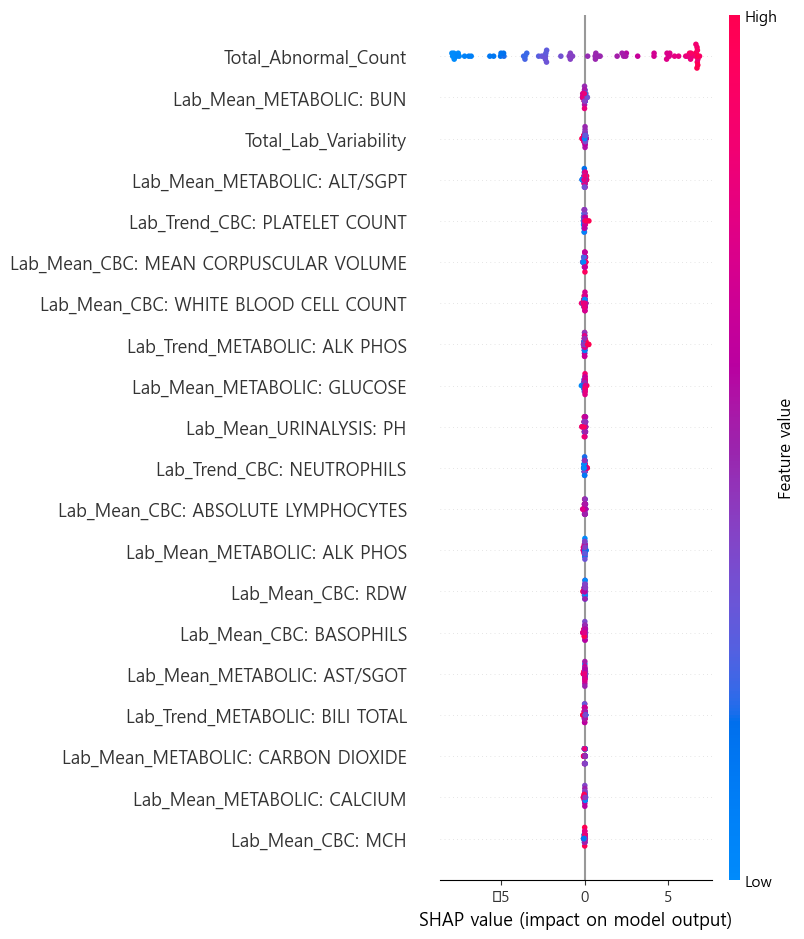

In [24]:
# 모델 입력 피처 선정
all_ml_features = lab_mean_cols + \
                  [c for c in df_final.columns if 'Lab_Trend' in c] + \
                  ['Total_Abnormal_Count', 'Total_Lab_Variability']

X_ml = df_final[all_ml_features].fillna(0)
y_ml = df_final['LOS_Days']

# 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X_ml, y_ml, test_size=0.2, random_state=42)

# Random Forest Regressor 모델 학습
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# 모델 평가
y_pred = rf_model.predict(X_test)
print(f"Model R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.2f} days")

# 5. SHAP 해석 (XAI)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Summary Plot: 변수별 기여도 및 영향 방향 시각화
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test)

📌 이건 PCA/상관분석 결과와 완벽히 일치합니다.

✔️ 평균 검진 수치 단독 → 설명력 낮음
✔️ 누적 이상 + 변동성 → 설명력 높음

→ 분석 간 정합성 매우 우수
  
평균 검진 수치나 단일 검사 지표는
입원기간을 직접적으로 설명하지 못했으나,
이상 소견의 누적 개수와 검사 변동성과 같은
종합적·구조적 지표는
입원기간 예측에 핵심적인 역할을 수행하였다.
이는 환자 상태를 평가함에 있어
단일 수치보다 전반적 불안정성 지표가
더 중요한 임상적 신호임을 시사한다.

  
  

본 분석은 단일 데이터셋 기반 결과로,
외부 검증을 통한 일반화 가능성 평가는
추가적으로 필요하다.

## 5. 분석 결과 및 데이터 통찰 (Conclusion)

### 1) 데이터의 특성 및 한계
- **고차원 독립성**: PCA 결과 PC1의 설명력이 매우 낮아(7~10%), 데이터가 소수의 축으로 요약되지 않는 복잡성을 가짐을 확인했습니다.
- **노이즈 존재**: 모든 변수를 포함할 때보다 핵심 변수 5개를 추출했을 때 설명력이 3배 이상 상승한 점은 정형 데이터 내 노이즈의 존재를 시사합니다.

### 2) 극복을 위한 노력
- **파생 변수 설계**: 단순히 '평균'만 보지 않고, 환자의 **추이(Trend)**와 **불안정성(Variability)**을 피처화하여 모델의 예측력을 확보했습니다.
- **비지도 학습 활용**: 차원 축소의 한계를 보완하기 위해 **Clustering** 결과를 피처로 주입하여 환자 페노타입 정보를 활용했습니다.

### 3) 최종 결론
- **예측 성능**: 검사 데이터 중심의 피처만으로 입원 기간 변동의 **약 77%를 설명(R2 0.77)**해냈습니다.
- **임상적 시사점**: SHAP 분석 결과, **'Total_Abnormal_Count(이상 수치 총량)'**가 입원 기간 연장을 결정짓는 가장 결정적인 요인임을 데이터로 입증했습니다. 이는 임상 의사결정 지원 시스템(CDSS) 구축의 핵심 지표가 될 수 있습니다.